# Week 6 Final Submission - Baseline Triage Models

**Student:** Vishal Baboolal  
**Project:** AI-Assisted Emergency Department Triage  
**Random seed:** `42`

This notebook trains and compares:

1. a stratified random-guess baseline;
2. logistic regression;
3. a bounded decision tree.

The primary clinical safety metric is ESI Level 1 recall.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)

RANDOM_STATE = 42
TREE_MAX_DEPTH = 12
LABELS = [1, 2, 3, 4, 5]

print("Libraries loaded.")
print("Random seed:", RANDOM_STATE)

Libraries loaded.
Random seed: 42


## 1. Load the cleaned Week 5 dataset

The patient-level dataset is not committed to the public repository. In Colab, upload `data_cleaned_week5.csv` to `/content/` or place it in Google Drive.

In [2]:
candidate_paths = [
    Path("data_cleaned_week5.csv"),
    Path("../data/data_cleaned_week5.csv"),
    Path("/content/data_cleaned_week5.csv"),
    Path("/content/drive/MyDrive/data_cleaned_week5.csv"),
    Path("/mnt/data/data_cleaned_week5.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Upload data_cleaned_week5.csv or update DATA_PATH to its location."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded {df.shape[0]:,} patient visits and {df.shape[1]} columns.")
print("\nTarget distribution:")
print(df["esi"].value_counts().sort_index())

Loaded 55,121 patient visits and 225 columns.

Target distribution:
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


## 2. Select pre-triage features and remove leakage

`disposition` and `previousdispo` are post-triage outcomes. Administrative and fairness-sensitive demographic fields are excluded from this first clinical baseline.

In [3]:
TARGET = "esi"

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status",
]
ADMIN = [
    "dep_name", "arrivalmode", "arrivalmonth",
    "arrivalday", "arrivalhour_bin",
]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [
    c for c in df.columns
    if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS
]

X = df[FEATURES]
y = df[TARGET]

print(f"Model input features: {len(FEATURES)}")
print(f"Missing values in model matrix: {int(X.isna().sum().sum())}")
print(
    "All model features numeric:",
    all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns),
)

Model input features: 208
Missing values in model matrix: 0
All model features numeric: True


## 3. Create the required 80/20 stratified split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records:  {len(X_test):,}")
print("\nTest-set class counts:")
print(y_test.value_counts().sort_index())

Training records: 44,096
Testing records:  11,025

Test-set class counts:
esi
1      16
2    3585
3    5402
4    1779
5     243
Name: count, dtype: int64


## 4. Train the stratified random baseline

In [5]:
dummy = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE,
)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print(
    "Stratified random baseline accuracy:",
    f"{accuracy_score(y_test, pred_dummy):.3f}",
)

Stratified random baseline accuracy: 0.375


## 5. Train logistic regression

The scaler is fitted only on the training set and then applied to the held-out test set.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

print(
    "Logistic-regression accuracy:",
    f"{accuracy_score(y_test, pred_logreg):.3f}",
)

Logistic-regression accuracy: 0.667


## 6. Train the bounded decision tree

`max_depth=12` limits complexity and reduces the risk of an unrestricted tree memorising noise. It is still deep enough to test non-linear clinical rules across five ESI classes.

In [7]:
tree = DecisionTreeClassifier(
    max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(
    "Decision-tree accuracy:",
    f"{accuracy_score(y_test, pred_tree):.3f}",
)
print("Learned tree depth:", tree.get_depth())
print("Leaf nodes:", tree.get_n_leaves())

Decision-tree accuracy: 0.585
Learned tree depth: 12
Leaf nodes: 306


## 7. Compare all models on the same metrics

In [8]:
def summarise_model(name, predictions):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "esi1_recall": recall_score(
            y_test,
            predictions,
            labels=[1],
            average=None,
            zero_division=0,
        )[0],
        "esi2_recall": recall_score(
            y_test,
            predictions,
            labels=[2],
            average=None,
            zero_division=0,
        )[0],
    }

comparison = pd.DataFrame([
    summarise_model("Stratified random baseline", pred_dummy),
    summarise_model("Logistic regression", pred_logreg),
    summarise_model(
        f"Decision tree (max_depth={TREE_MAX_DEPTH})",
        pred_tree,
    ),
])

comparison.round(3)

,model,accuracy,macro_f1,weighted_f1,esi1_recall,esi2_recall
0,Stratified random baseline,0.375,0.204,0.375,0.000,0.327
1,Logistic regression,0.667,0.492,0.661,0.250,0.608
2,Decision tree (max_depth=12),0.585,0.303,0.535,0.062,0.410


### Why macro and weighted F1 differ

Macro F1 gives every ESI class equal weight. Weighted F1 gives more influence to common ESI classes. A much higher weighted score therefore warns that the model performs better on common classes than on rare but clinically important classes.

## 8. Logistic-regression class-level results

In [9]:
print(classification_report(
    y_test,
    pred_logreg,
    labels=LABELS,
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

           1      0.444     0.250     0.320        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.587     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.582     0.463     0.492     11025
weighted avg      0.666     0.667     0.661     11025



## 9. Decision-tree class-level results

In [10]:
print(classification_report(
    y_test,
    pred_tree,
    labels=LABELS,
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

           1      0.500     0.062     0.111        16
           2      0.724     0.410     0.524      3585
           3      0.550     0.882     0.678      5402
           4      0.628     0.120     0.201      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.585     11025
   macro avg      0.481     0.295     0.303     11025
weighted avg      0.607     0.585     0.535     11025



## 10. Logistic-regression confusion matrix

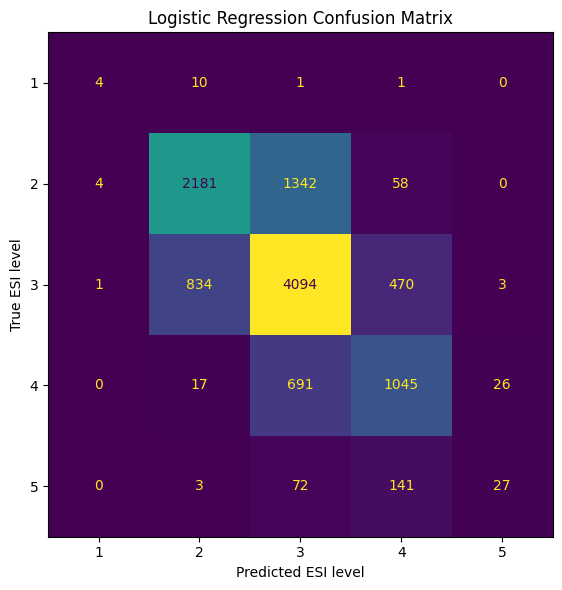

In [11]:
cm_logreg = confusion_matrix(
    y_test,
    pred_logreg,
    labels=LABELS,
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=LABELS,
).plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)
ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted ESI level")
ax.set_ylabel("True ESI level")
plt.tight_layout()
plt.show()

## 11. Decision-tree confusion matrix

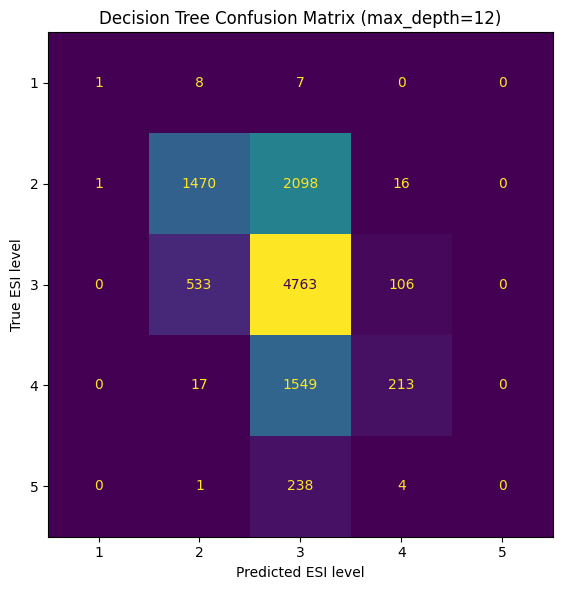

In [12]:
cm_tree = confusion_matrix(
    y_test,
    pred_tree,
    labels=LABELS,
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=LABELS,
).plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)
ax.set_title(
    f"Decision Tree Confusion Matrix (max_depth={TREE_MAX_DEPTH})"
)
ax.set_xlabel("Predicted ESI level")
ax.set_ylabel("True ESI level")
plt.tight_layout()
plt.show()

## 12. Clinical metric justification and failure-mode reflection

**Primary metric: ESI Level 1 recall.**

Accuracy is not the main safety measure because ESI Level 1 represents only 77 of 55,121 encounters. The logistic-regression model identified **4 of 16** true Level 1 patients in the held-out test set and missed **12**. The decision tree identified **1 of 16** and missed **15**.

A missed ESI Level 1 case could delay immediate resuscitation, airway support, haemodynamic stabilisation, or another life-saving intervention. Neither baseline is safe for deployment.

The most concerning missed patients are likely to be critical presentations with subtle symptoms or initially near-normal vital signs. The next stage should address class imbalance, inspect de-identified error summaries, evaluate subgroup performance, and validate locally before any silent clinical pilot.

## Final conclusion

Both trained models beat random guessing on some overall measures, confirming that the dataset contains useful predictive signal. Logistic regression is the stronger overall baseline. However, its ESI Level 1 detection remains inadequate, and the bounded decision tree performs worse. These models should remain offline research baselines only.